# Spread Mean-Reversion Backtester — HyperLiquid vs MT5 (JPY)

This notebook runs the strategy from `spread_backtester.py` and adds three things
on top of a single backtest run:

1. **Sharpe & Sortino ratios** (daily-resampled, annualized) — a proper risk-adjusted
   return measure, instead of eyeballing win rate / drawdown.
2. **Train/test split** — the kill-switch threshold (and every other parameter) is
   frozen once, then checked on a held-out window it was never tuned against.
3. **Walk-forward test** — the same frozen strategy run across several sequential
   time windows, to see if performance holds up consistently or was a one-window fluke.

**Important:** the threshold and all strategy parameters below are picked *once*,
up front, based on the report's original bands + your risk tolerance — and then
never touched again in response to how good or bad a particular window's result
looks. Re-tuning after seeing results is exactly the overfitting trap from before.

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from spread_backtester import (
    StrategyConfig, SpreadBacktester, load_price_data,
    train_test_split_test, walk_forward_test,
)

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load data

Loads your real MT5 CSV export and pulls the matching HyperLiquid historical
window over REST, joined on timestamp. If `mt5_csv_path` is left as `None`
(e.g. running this without internet access), it falls back to synthetic data
so the notebook still runs end-to-end for testing the mechanics.

In [27]:
data = load_price_data(
    mt5_csv_path="USDJPYM1.csv",   # your real export, same folder as this notebook
    hl_coin="xyz:JPY",
    hl_interval="1m",
    mt5_tz=None,   # set your broker's server timezone if known, e.g. "Etc/GMT-3"
)

print(f"{len(data):,} aligned bars")
print(f"{data.index.min()}  ->  {data.index.max()}")
data.tail()

5,184 aligned bars
2026-08-10 20:12:00+00:00  ->  2026-08-14 10:34:00+00:00


,hl_close,mt5_close
datetime,,
2026-08-14 10:31:00+00:00,159.13,159.288
2026-08-14 10:32:00+00:00,159.13,159.285
2026-08-14 10:33:00+00:00,159.13,159.282
2026-08-14 10:34:00+00:00,159.13,159.280
2026-08-14 10:34:00+00:00,159.13,159.280


## 2. Strategy configuration — frozen for the rest of this notebook

Pick this once. Every section below reuses `cfg` unchanged. If a result looks
bad, that's information about the strategy — not a cue to tweak `cfg` and
re-run until it looks better.

In [29]:
cfg = StrategyConfig(
    entry_sigma=1.5,
    exit_sigma=0.0,
    stop_sigma_extra=1.0,
    risk_pct_per_trade=0.01,
    max_drawdown_pct=0.15,          # <-- picked from risk tolerance, not tuned against results
    order_type="market",
    rolling=True,                   # rolling mu/sigma is more realistic than one static window
    lookback_bars=2000,             # ~1 trading day of 1-min bars
    starting_equity=10_000.0,

)
cfg

StrategyConfig(lookback_bars=2000, rolling=True, entry_sigma=1.5, exit_sigma=0.0, stop_sigma_extra=1.0, order_type='market', hl_taker_fee_pct=0.009, hl_maker_fee_pct=0.003, market_order_slippage_pct=0.01, slippage_curve={}, mt5_spread=0.001, mt5_fee=0.0, reference_price=159.308, risk_pct_per_trade=0.01, point_value=0.006277148667989053, max_drawdown_pct=0.15, starting_equity=10000.0)

## 3. Full-period backtest

Baseline run across the entire loaded window, with Sharpe/Sortino now included
in the summary.

In [31]:
bt_full = SpreadBacktester(data, cfg)
summary_full = bt_full.run()

for k, v in summary_full.items():
    print(f"{k:>22}: {v}")

                trades: 29
          win_rate_pct: 13.793103448275861
         total_net_pnl: -1531.6234827055491
             avg_trade: -52.81460285191549
      max_drawdown_pct: 15.380848446413054
         ending_equity: 8468.376517294448
 halted_by_kill_switch: True
             halted_at: 2026-08-12 09:45:00+00:00
                sharpe: -9.165151389911678
               sortino: nan
           n_daily_obs: 3


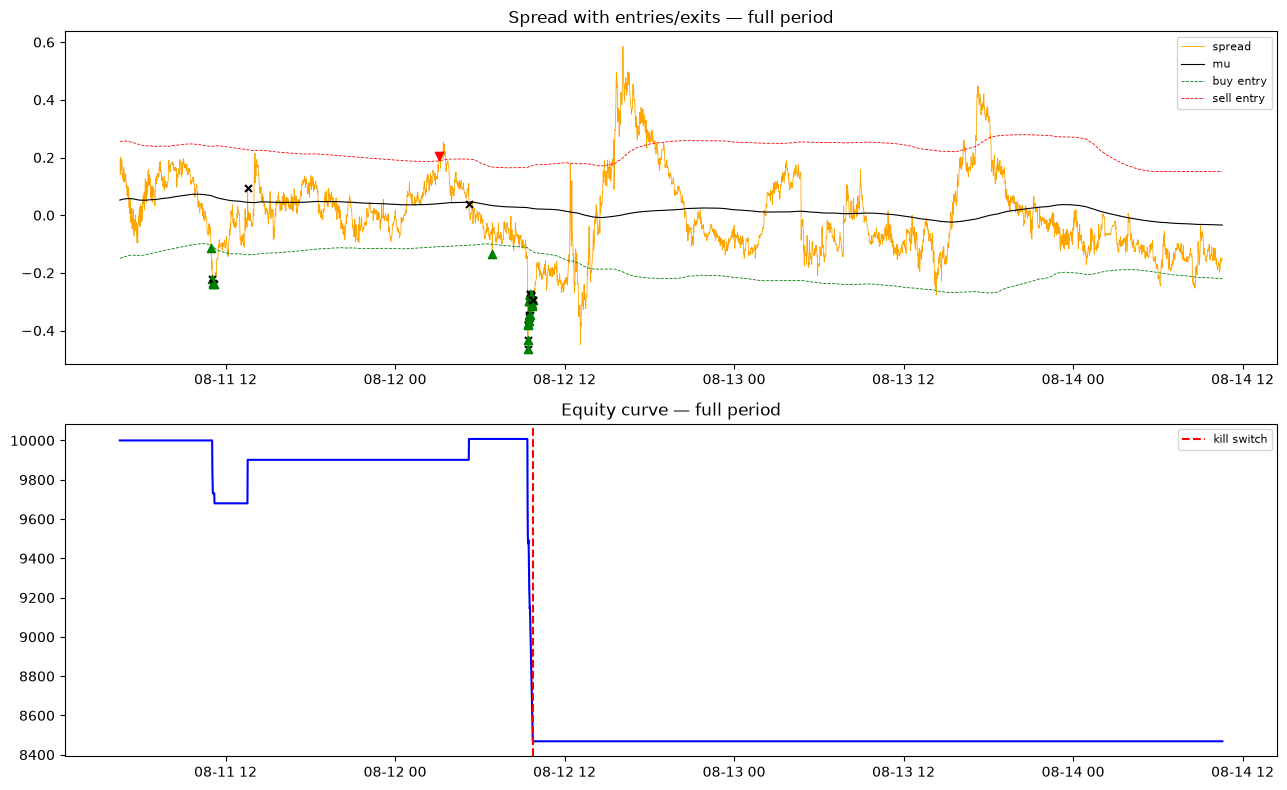

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

d = bt_full.bands_df
axes[0].plot(d.index, d["spread"], color="orange", linewidth=0.6, label="spread")
axes[0].plot(d.index, d["mu"], color="black", linewidth=0.8, label="mu")
axes[0].plot(d.index, d["buy_entry"], "--", color="green", linewidth=0.6, label="buy entry")
axes[0].plot(d.index, d["sell_entry"], "--", color="red", linewidth=0.6, label="sell entry")
for t in bt_full.trades:
    marker = "^" if t.side == "long" else "v"
    color = "green" if t.side == "long" else "red"
    axes[0].scatter(t.entry_time, t.entry_price, marker=marker, color=color, s=35, zorder=5)
    if t.exit_time:
        axes[0].scatter(t.exit_time, t.exit_price, marker="x", color="black", s=25, zorder=5)
axes[0].set_title("Spread with entries/exits — full period")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot(bt_full.equity_df.index, bt_full.equity_df["equity"], color="blue")
axes[1].set_title("Equity curve — full period")
if bt_full.halted_at:
    axes[1].axvline(bt_full.halted_at, color="red", linestyle="--", label="kill switch")
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Train / test split (out-of-sample check)

First half of the data = train (in-sample), second half = test (out-of-sample).
`cfg` is **not** re-tuned between the two — this is the direct check on whether
results generalize to data the strategy wasn't (even implicitly) fit to.

In [34]:
oos = train_test_split_test(data, cfg, train_frac=0.5)
bt_train, stats_train = oos["train"]
bt_test, stats_test = oos["test"]

comparison = pd.DataFrame([stats_train, stats_test], index=["train (in-sample)", "test (out-of-sample)"])
comparison[["trades", "win_rate_pct", "total_net_pnl", "max_drawdown_pct", "sharpe", "sortino", "halted_by_kill_switch"]]

,trades,win_rate_pct,total_net_pnl,max_drawdown_pct,sharpe,sortino,halted_by_kill_switch
train (in-sample),29,13.793103,-1531.623483,15.380848,NaN,None,True
test (out-of-sample),5,60.000000,269.700870,1.923941,11.224972,None,False


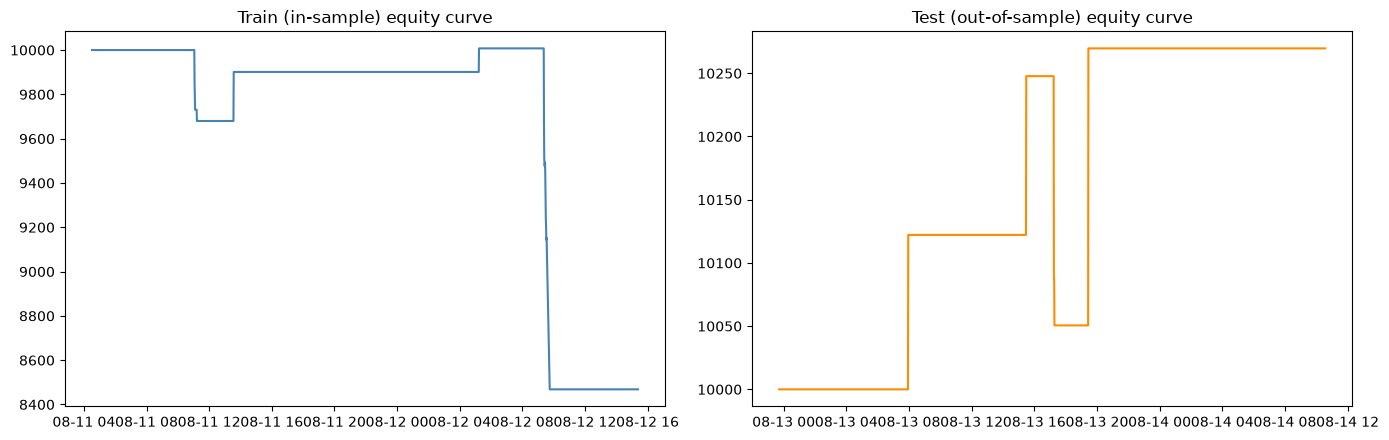

If test performance is much worse than train performance, that's evidence
the strategy (or the specific parameter values) doesn't generalize --
it was fitting noise in the train window rather than a persistent edge.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
axes[0].plot(bt_train.equity_df.index, bt_train.equity_df["equity"], color="steelblue")
axes[0].set_title("Train (in-sample) equity curve")
axes[1].plot(bt_test.equity_df.index, bt_test.equity_df["equity"], color="darkorange")
axes[1].set_title("Test (out-of-sample) equity curve")
plt.tight_layout()
plt.show()

print("If test performance is much worse than train performance, that's evidence")
print("the strategy (or the specific parameter values) doesn't generalize --")
print("it was fitting noise in the train window rather than a persistent edge.")

## 5. Walk-forward test

Splits the full period into several sequential, non-overlapping folds and runs
the **same frozen `cfg`** on each one in order (equity compounds fold-to-fold,
mimicking actually trading straight through time). A strategy with real edge
should hold up reasonably across most folds — not just look good in one.

In [36]:
wf = walk_forward_test(data, cfg, n_folds=3, compound=True)
fold_stats = wf["fold_stats"]

cols = ["fold", "fold_start", "fold_end", "trades", "win_rate_pct",
        "total_net_pnl", "max_drawdown_pct", "sharpe", "sortino", "ending_equity"]
fold_stats[cols]

,fold,fold_start,fold_end,trades,win_rate_pct,total_net_pnl,max_drawdown_pct,sharpe,sortino,ending_equity
0,1,2026-08-10 20:12:00+00:00,2026-08-12 00:59:00+00:00,5,20.000000,-98.712852,3.201796,None,None,9901.287148
1,2,2026-08-12 01:00:00+00:00,2026-08-13 05:47:00+00:00,26,7.692308,-1511.947988,15.270217,None,None,8389.339160
2,3,2026-08-13 05:48:00+00:00,2026-08-14 10:34:00+00:00,17,5.882353,-1291.411216,15.393480,None,None,7097.927944


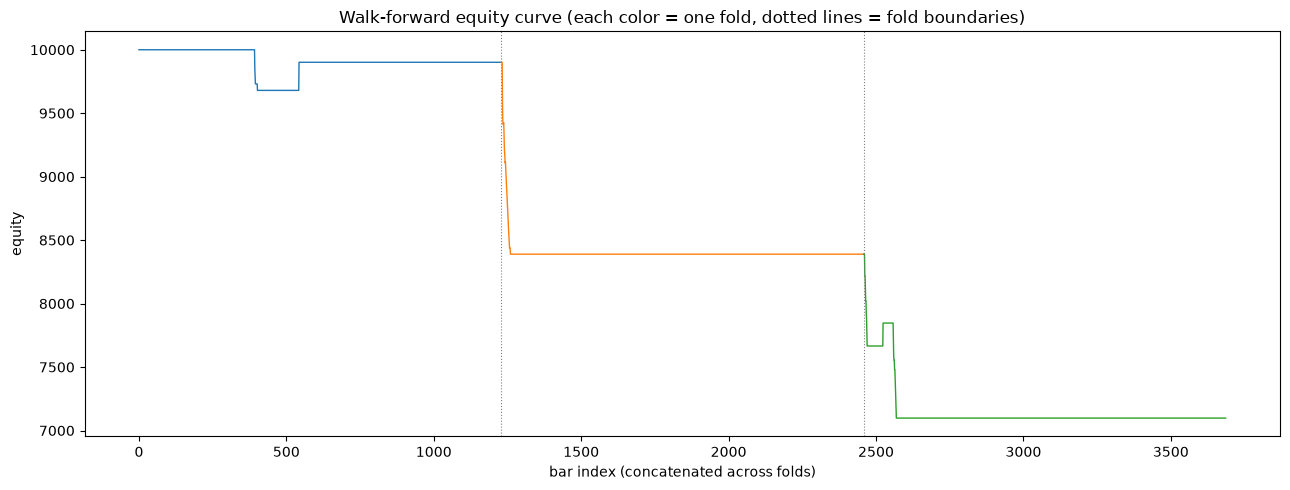

Win rate across folds: mean 11.2%, std 7.7pp
Net PnL across folds:  mean -967.36, std 760.31

High variance across folds (win rate or PnL swinging wildly fold-to-fold)
is itself a finding: it means the full-period backtest result depends a lot
on WHICH window you happened to test, not on a stable, repeatable edge.


In [37]:
fig, ax = plt.subplots(figsize=(13, 5))

offset = 0
boundaries = []
for bt in wf["backtesters"]:
    eq = bt.equity_df["equity"]
    x = range(offset, offset + len(eq))
    ax.plot(x, eq.values, linewidth=1)
    offset += len(eq)
    boundaries.append(offset)

for b in boundaries[:-1]:
    ax.axvline(b, color="gray", linestyle=":", linewidth=0.8)

ax.set_title("Walk-forward equity curve (each color = one fold, dotted lines = fold boundaries)")
ax.set_xlabel("bar index (concatenated across folds)")
ax.set_ylabel("equity")
plt.tight_layout()
plt.show()

print(f"Win rate across folds: mean {fold_stats['win_rate_pct'].mean():.1f}%, "
      f"std {fold_stats['win_rate_pct'].std():.1f}pp")
print(f"Net PnL across folds:  mean {fold_stats['total_net_pnl'].mean():.2f}, "
      f"std {fold_stats['total_net_pnl'].std():.2f}")
print()
print("High variance across folds (win rate or PnL swinging wildly fold-to-fold)")
print("is itself a finding: it means the full-period backtest result depends a lot")
print("on WHICH window you happened to test, not on a stable, repeatable edge.")

## Reading these results

- **Sharpe/Sortino** here are computed on daily-resampled equity, annualized —
  treat single-digit-observation windows (very short backtests) with caution;
  the `n_daily_obs` field in each summary tells you how many daily data points
  went into the ratio.
- **Train vs test**: a real edge should not evaporate or reverse sign out-of-sample.
  If it does, the in-sample result was likely noise, not signal.
- **Walk-forward variance**: low variance across folds is a much stronger signal
  of a repeatable edge than one good full-period number. High variance means the
  strategy's apparent performance is dominated by which specific dates you tested.
- None of this constitutes investment advice, and a clean walk-forward result on
  historical data is still not a guarantee of future live performance —
  execution risk, changing market regimes, and the calibration caveats already
  discussed (point_value, slippage curve, fee tier) all still apply.